Starting with the closed form equation (normal). Derived from notes: 
$$
X^\top X w = X^\top y
$$

Solving for $(w)$

$$
w = (X^\top X)^{-1} X^\top y
$$

In NumPy, this can be written as:

```python
w = np.linalg.inv(X.T @ X) @ X.T @ y
```

A better numerical approach is to solve the linear system directly:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```

This directly solves:

$$
X^\top X w = X^\top y
$$

for $(w)$.

If you want the model to learn an intercept term, add a column of ones to \(X\):

```python
X = np.c_[np.ones(n), x]
```

Then:

```python
w[0]  # intercept
w[1]  # slope
```

In [464]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 



A simple data set with:

$$y = 3x + 5$$

using closed form

$$
w = (X^\top X)^{-1}X^\top y
$$

In [465]:
# simple data: y = 3x + 5
x = np.array([1, 2, 3, 4, 5 ])
y = np.array([8, 11, 14, 17, 20])

# add bias column for the intercept 
X = np.c_[np.ones(len(x)), x]

# closed form solution: 

# w = (X^\top X)^{-1}X^\top y
w = np.linalg.inv(X.T@ X)@X.T@y

print(w)

# output should be [5, 3.]

intercept = w[0]
slope =     w[1]

print("intercept: ", intercept)
print("slope: ", slope)


[5. 3.]
intercept:  5.000000000000013
slope:  3.0000000000000018


We can illustrate this by:

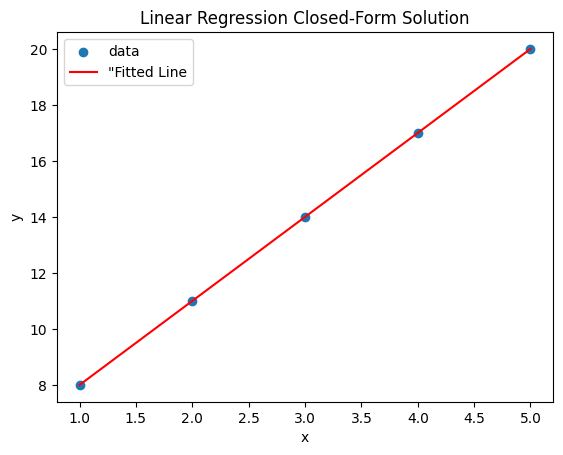

In [466]:
# get the predictions
y_pred = X@w 

# plot data points

plt.scatter(x, y, label = "data")

# plot the fitted line
plt.plot(x, y_pred, color = 'red', label = '"Fitted Line' )

plt.xlabel("x")
plt.ylabel('y')
plt.title("Linear Regression Closed-Form Solution")
plt.legend()
plt.show()


## Adding Noise to the Closed-Form Solution

In real data, the outputs usually do not lie perfectly on a line. Instead of assuming the model has no intercept:

$$
\mathbb{E}[y|\mathbf{x}] = \mathbf{w}^\top \mathbf{x}
$$

we often include an intercept, also called a **bias** term:

$$
\mathbb{E}[y|\mathbf{x}] = \mathbf{w}^\top \mathbf{x} + b
$$

This means the average value of `y`, given `x`, follows a linear model with a bias term.

However, real observed data also contains noise. So the actual observation is modeled as:

$$
y = \mathbf{w}^\top \mathbf{x} + b + \epsilon
$$

where `epsilon` is the noise/error term.

To use the normal equation, we can absorb the bias term into the weight vector by adding a column of ones to `X`:

```python
X = np.c_[np.ones(n), X]
```

Then the model becomes:

$$
y = Xw + \epsilon
$$

and the normal equation is still:

$$
X^\top Xw = X^\top y
$$

Solving for `w`:

$$
w = (X^\top X)^{-1}X^\top y
$$

In NumPy, it is better to write:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```

Now:

```python
w[0]   # bias/intercept
w[1:]  # feature weights
```

This can be demonstrated:

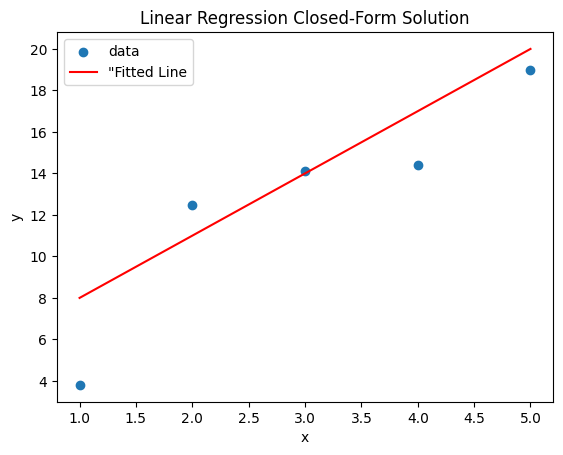

In [467]:
# Linear Regression with noise

y = 3 * x + 5 + np.random.randn(len(x))*2

y_pred = X@w 

# plot data points

plt.scatter(x, y, label = "data")

# plot the fitted line
plt.plot(x, y_pred, color = 'red', label = '"Fitted Line' )

plt.xlabel("x")
plt.ylabel('y')
plt.title("Linear Regression Closed-Form Solution")
plt.legend()
plt.show()




## Evaluating the Model

After fitting the model, we need to measure how well it predicts the true values.

The model makes predictions using:

$$
\hat{y} = Xw
$$

where `y_hat` is the predicted output.

In NumPy:

```python
y_pred = X @ w
```

The residuals, or errors, are the differences between the true values and the predicted values:

$$
r = y - \hat{y}
$$

In NumPy:

```python
residuals = y - y_pred
```

A good model should have small residuals. If the residuals are large, then the model is making poor predictions.

### Mean Squared Error

Mean Squared Error, or `MSE`, measures the average squared error between the true values and the predicted values:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

In NumPy:

```python
mse = np.mean((y - y_pred) ** 2)
```

Because the errors are squared, **large mistakes are penalized more heavily**.

### Mean Absolute Error

Mean Absolute Error, or `MAE`, measures the average absolute error:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

In NumPy:

```python
mae = np.mean(np.abs(y - y_pred))
```

Unlike `MSE`, `MAE` treats errors more evenly because it does not square them.

### R-Squared

R-squared, written as `R2`, measures how much of the variation in `y` is explained by the model.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

In NumPy:

```python
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)
```

The denominator measures how bad the baseline model is. The baseline model always predicts the mean of `y`.

So:

```python
y_baseline = np.mean(y)
```

Interpretation:

```python
R2 = 1  # perfect fit
R2 = 0  # same as always predicting the mean
R2 < 0  # worse than always predicting the mean
```

### Full Evaluation Code

```python
# Predictions
y_pred = X @ w

# Errors / residuals
residuals = y - y_pred

# Mean Squared Error
mse = np.mean((y - y_pred) ** 2)

# Mean Absolute Error
mae = np.mean(np.abs(y - y_pred))

# R-squared
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
```

### Residual Plot

A residual plot helps us see whether the model is missing a pattern.

```python
import matplotlib.pyplot as plt

plt.scatter(x, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("x")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
```

If the residuals are randomly scattered around zero, the model is probably fitting well.

If the residuals show a clear pattern, then the model may be too simple.

Using the same dataset from above we have:

In [468]:
# simple data: y = 3x + 5
x = np.array([1, 2, 3, 4, 5 ])
y = np.array([8, 11, 14, 17, 20])

# add bias column for the intercept 
X = np.c_[np.ones(len(x)), x]

# closed form solution: 

# w = (X^\top X)^{-1}X^\top y
w = np.linalg.inv(X.T@ X)@X.T@y

print(w)

# output should be [5, 3.]

intercept = w[0]
slope =     w[1]

print("intercept: ", intercept)
print("slope: ", slope)


[5. 3.]
intercept:  5.000000000000013
slope:  3.0000000000000018


Now extracting the different predictors we get:

Predictions: [ 8. 11. 14. 17. 20.]
Actual y: [ 8 11 14 17 20]
Residuals: [-1.42108547e-14 -1.77635684e-14 -1.77635684e-14 -2.13162821e-14
 -2.13162821e-14]
MSE: 3.4836097574559883e-28
MAE: 1.8474111129762605e-14
R2: 1.0


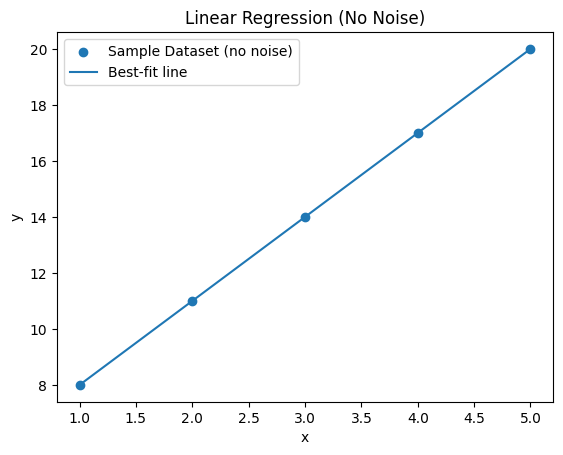

In [469]:
# predictions
y_pred = X @ w

print("Predictions:", y_pred)
print("Actual y:", y)

# residuals/errors
residuals = y - y_pred
print("Residuals:", residuals)

# evaluation metrics
mse = np.mean((y - y_pred) ** 2)
mae = np.mean(np.abs(y - y_pred))
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

plt.scatter(x, y, label="Sample Dataset (no noise)")

# Plot best-fit line
plt.plot(x, y_pred, label="Best-fit line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression (No Noise)")
plt.legend()
plt.show()

To make it more realistic we can add some noise:

w: [5.8  2.78]
intercept: 5.799999999999996
slope: 2.7800000000000007
predictions: [ 8.58 11.36 14.14 16.92 19.7 ]
actual y: [ 9.2 10.5 14.7 15.9 20.4]
MSE: 0.5935999999999992
MAE: 0.752
R2: 0.9630164980312017


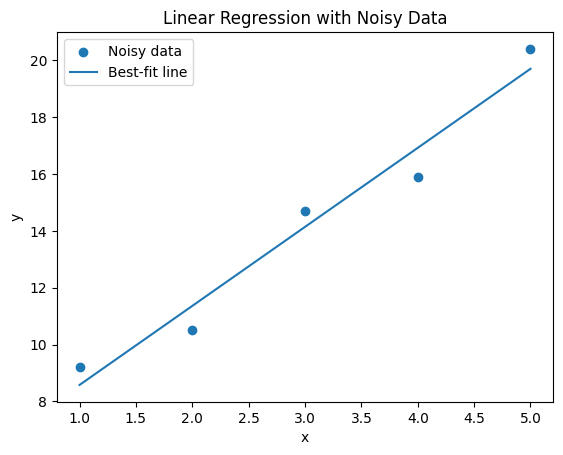

In [470]:
# noisy data: y = 3x + 5 + noise
x = np.array([1, 2, 3, 4, 5])
noise = np.array([1.2, -0.5, 0.7, -1.1, 0.4])
y = 3 * x + 5 + noise

# add bias column
X = np.c_[np.ones(len(x)), x]

# closed-form solution
w = np.linalg.solve(X.T @ X, X.T @ y)

# predictions
y_pred = X @ w

# evaluation
mse = np.mean((y - y_pred) ** 2)
mae = np.mean(np.abs(y - y_pred))
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("w:", w)
print("intercept:", w[0])
print("slope:", w[1])
print("predictions:", y_pred)
print("actual y:", y)
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

import matplotlib.pyplot as plt

# Plot noisy data points
plt.scatter(x, y, label="Noisy data")

# Plot best-fit line
plt.plot(x, y_pred, label="Best-fit line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Noisy Data")
plt.legend()
plt.show()

We can use more points to better visualize what this looks like:

## Math Behind the Linear Regression Code

We are generating noisy linear data from the true equation:

$$
y = 3x + 5 + \epsilon
$$

where `epsilon` is random noise.

In code:

```python
x = np.linspace(1, 10, 50)
noise = np.random.randn(len(x)) * 2
y = 3 * x + 5 + noise
```

This means the true relationship is:

$$
y_i = 3x_i + 5 + \epsilon_i
$$

for each data point `i`.

The model does not know the true slope `3` or intercept `5`. It only sees the data points and tries to learn the best values.

---

## Adding the Bias Column

A linear regression model with an intercept is:

$$
\hat{y} = w_0 + w_1x
$$

where:

- `w0` is the intercept
- `w1` is the slope
- `y_hat` is the prediction

To write this in matrix form, we add a column of ones to `X`:

```python
X = np.c_[np.ones(len(x)), x]
```

So if:

```python
x = [x1, x2, x3, ..., xn]
```

then `X` becomes:

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
$$

and the weight vector is:

$$
w =
\begin{bmatrix}
w_0 \\
w_1
\end{bmatrix}
$$

Now the prediction equation becomes:

$$
\hat{y} = Xw
$$

which means:

$$
\begin{bmatrix}
\hat{y}_1 \\
\hat{y}_2 \\
\hat{y}_3 \\
\vdots \\
\hat{y}_n
\end{bmatrix}
=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
w_0 \\
w_1
\end{bmatrix}
$$

So each prediction is:

$$
\hat{y}_i = w_0 + w_1x_i
$$

---

## Closed-Form Solution

The goal is to find the best `w` that makes the predictions `Xw` close to the real values `y`.

We minimize the squared error:

$$
RSS(w) = \frac{1}{2}\|Xw - y\|_2^2
$$

Taking the gradient and setting it equal to zero gives the normal equation:

$$
X^\top Xw = X^\top y
$$

Solving for `w` gives:

$$
w = (X^\top X)^{-1}X^\top y
$$

In code, instead of directly computing the inverse, we solve the system:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```

This line solves:

$$
X^\top Xw = X^\top y
$$

for `w`.

So after this line:

```python
w[0]  # learned intercept
w[1]  # learned slope
```

Ideally, since the data came from:

$$
y = 3x + 5 + \epsilon
$$

we expect:

```python
w[0] ≈ 5
w[1] ≈ 3
```

They will not be exactly `5` and `3` because we added noise.

---

## Making Predictions

Once we have learned `w`, we compute predictions using:

```python
y_pred = X @ w
```

Mathematically:

$$
\hat{y} = Xw
$$

or for each point:

$$
\hat{y}_i = w_0 + w_1x_i
$$

---

## Evaluating the Model

After predicting, we compare the true values `y` with the predictions `y_pred`.

The error for each point is:

$$
e_i = y_i - \hat{y}_i
$$

In vector form:

$$
e = y - \hat{y}
$$

---

## Mean Squared Error

Mean Squared Error measures the average squared error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

In code:

```python
mse = np.mean((y - y_pred) ** 2)
```

A smaller `MSE` means the predictions are closer to the true values.

---

## Mean Absolute Error

Mean Absolute Error measures the average absolute error:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

In code:

```python
mae = np.mean(np.abs(y - y_pred))
```

`MAE` is easier to interpret because it is in the same units as `y`.

---

## R-Squared

R-squared measures how much better the model is compared to simply predicting the mean of `y`.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

In code:

```python
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)
```

The numerator is the model error:

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

The denominator is the baseline error:

$$
\sum_{i=1}^{n}(y_i - \bar{y})^2
$$

The baseline model always predicts the mean:

$$
\hat{y} = \bar{y}
$$

Interpretation:

```python
R2 = 1  # perfect model
R2 = 0  # model is no better than predicting the mean
R2 < 0  # model is worse than predicting the mean
```

Since your data is mostly linear, your `R2` should be fairly high.

intercept: 7.006434924947511
slope: 2.6863061126688517
MSE: 4.3758700917125655
MAE: 1.6142630971842067
R2: 0.9205451107570742


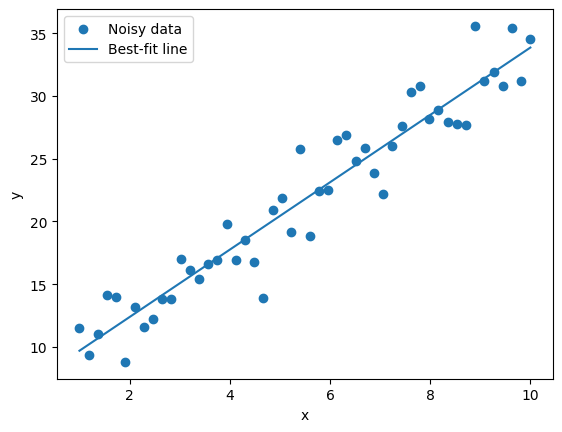

In [471]:
# generate more data
np.random.seed(0)

x = np.linspace(1, 10, 50)
noise = np.random.randn(len(x)) * 2
y = 3 * x + 5 + noise

# add bias column to offset 
X = np.c_[np.ones(len(x)), x]

# closed-form solution
w = np.linalg.solve(X.T @ X, X.T @ y)

# predictions
y_pred = X @ w

# evaluation
mse = np.mean((y - y_pred) ** 2)
mae = np.mean(np.abs(y - y_pred))
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("intercept:", w[0])
print("slope:", w[1])
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

# plot
plt.scatter(x, y, label="Noisy data")
plt.plot(x, y_pred, label="Best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Gradient Descent for Linear Regression

So far, we solved linear regression using the closed-form normal equation:

$$
X^\top Xw = X^\top y
$$

which gives:

$$
w = (X^\top X)^{-1}X^\top y
$$

This directly solves for the best weight vector `w`.

However, many machine learning models do not have a closed-form solution. Instead, they are trained using iterative optimization methods like **gradient descent**.

---

## Objective Function

For linear regression, we want our predictions to be close to the true values.

The prediction is:

$$
\hat{y} = Xw
$$

The residual/error is:

$$
y - \hat{y}
$$

Using the notation from the notes, the residual sum of squares is:

$$
RSS(w) = \frac{1}{2}\|Xw - y\|_2^2
$$

Equivalently:

$$
RSS(w) = \frac{1}{2}(Xw - y)^\top(Xw - y)
$$

The goal is to find the weight vector `w` that minimizes this error:

$$
\hat{w} = \arg\min_w RSS(w)
$$

---

## Gradient of the Loss

From the notes, the gradient of the RSS objective is:

$$
\nabla_w RSS(w) = X^\top Xw - X^\top y
$$

This can also be written as:

$$
\nabla_w RSS(w) = X^\top(Xw - y)
$$

because:

$$
X^\top(Xw - y) = X^\top Xw - X^\top y
$$

The term `Xw - y` is the prediction error.

So the gradient tells us how to change `w` in order to reduce the error.

---

## Gradient Descent Update Rule

Gradient descent updates the weights by moving in the opposite direction of the gradient:

$$
w := w - \alpha \nabla_w RSS(w)
$$

where:

- `w` is the weight vector
- `alpha` is the learning rate
- `gradient` tells us the direction of steepest increase
- subtracting the gradient moves us toward lower error

Substituting the linear regression gradient:

$$
w := w - \alpha X^\top(Xw - y)
$$

This is the main update rule for gradient descent.

---

## Why This Is Different From the Closed-Form Solution

The closed-form solution solves everything in one step:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```

Gradient descent starts with an initial guess, usually zeros:

```python
w = np.zeros(X.shape[1])
```

Then it repeatedly updates the weights:

```python
w = w - learning_rate * gradient
```

After many updates, `w` should get close to the closed-form solution.

---


## Using MSE Instead of RSS

Sometimes we use Mean Squared Error instead of RSS:

$$
MSE(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

The gradient of MSE is:

$$
\nabla_w MSE(w) = \frac{2}{n}X^\top(Xw - y)
$$

Then the update rule becomes:

$$
w := w - \alpha \frac{2}{n}X^\top(Xw - y)
$$

In code:

```python
n = len(y)

for epoch in range(epochs):
    y_pred = X @ w
    error = y_pred - y

    gradient = (2 / n) * X.T @ error

    w = w - learning_rate * gradient
```

Both versions are doing the same idea. The only difference is the scaling factor.

If gradient descent is working, the loss should decrease over time.

---

## Main Idea

Closed-form linear regression solves for `w` directly:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```

Gradient descent learns `w` step by step:

```python
w = w - learning_rate * gradient
```

This matters because gradient descent is used in many models that do not have a simple closed-form solution, including logistic regression, neural networks, CNNs, and transformers.

## Gradient Descent Using RSS

In [472]:
# generate data
np.random.seed(0) 

x = np.linspace(1, 10, 50)
noise = np.random.randn(len(x)) * 2

y = 3 * x + 5 + noise

# add bias column 
X = np.c_[np.ones(len(x)), x]

# initialize weights 
w = np.zeros(X.shape[1])

# hyperparameters 
learning_rate = 0.001
epochs = 1000

# gradient descent loop
for epoch in range(epochs):
    # predictions
    y_pred = X @ w
    
    #error
    error = y_pred - y
    
    # gradient of RSS
    gradient = X.T @ error 
    
    # update weights
    w = w - learning_rate * gradient 

print("Gradient Descent Weights", w)
print("Intercept: ", w[0])
print("Slope: ", w[1])

Gradient Descent Weights [7.00582259 2.68639691]
Intercept:  7.005822589646327
Slope:  2.6863969119939113


## Gradient Descent Using MSE

In [473]:
# generate data
np.random.seed(0)

x = np.linspace(1, 10, 50)
noise = np.random.randn(len(x)) * 2
y = 3 * x + 5 + noise

# add bias column
X = np.c_[np.ones(len(x)), x]

# initialize weights
w = np.zeros(X.shape[1])

# hyperparameters
learning_rate = 0.01
epochs = 1000
n = len(y)

# store loss values
loss_history = []

# gradient descent loop
for epoch in range(epochs):
    # predictions
    y_pred = X @ w

    # error
    error = y_pred - y

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # gradient of MSE
    gradient = (2 / n) * X.T @ error

    # update weights
    w = w - learning_rate * gradient

print("Gradient descent weights:", w)
print("intercept:", w[0])
print("slope:", w[1])

# compare with closed-form solution
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

print("Closed-form weights:", w_closed)
print("Loss", loss_history)


Gradient descent weights: [6.84587218 2.71011495]
intercept: 6.845872182606648
slope: 2.7101149451925446
Closed-form weights: [7.00643492 2.68630611]
Loss [np.float64(529.4907666321528), np.float64(41.540690255608), np.float64(13.805436470240451), np.float64(12.178128578661708), np.float64(12.03229646064867), np.float64(11.97090113853226), np.float64(11.914687027576266), np.float64(11.859155153660543), np.float64(11.804047434770741), np.float64(11.74934639169574), np.float64(11.69504821529333), np.float64(11.641149892659712), np.float64(11.587648476656636), np.float64(11.534541044320704), np.float64(11.481824694353413), np.float64(11.429496546829357), np.float64(11.377553743031296), np.float64(11.325993445293557), np.float64(11.27481283684703), np.float64(11.224009121665222), np.float64(11.173579524311556), np.float64(11.123521289787725), np.float64(11.073831683383187), np.float64(11.024507990525771), np.float64(10.97554751663338), np.float64(10.92694758696677), np.float64(10.878705546

## Different Learning Rates

To see how different learning rates affect the dataset we can show this by iterating through different values. 

For context: 

- learning_rate = 0.001  -> usually slow but stable
- learning_rate = 0.01   -> usually good
- learning_rate = 0.1    -> might be unstable
- learning_rate = 1.0    -> will probably diverge

In [474]:

# generate data
np.random.seed(0)

x = np.linspace(1, 10, 50)
noise = np.random.randn(len(x)) * 2
y = 3 * x + 5 + noise

# add bias column
X = np.c_[np.ones(len(x)), x]

# closed-form solution for comparison
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

# learning rates to test
learning_rates = [0.001, 0.01, 0.1, 1.0]

epochs = 1000
n = len(y)

results = {}

for lr in learning_rates:
    # initialize weights fresh for each learning rate
    w = np.zeros(X.shape[1])

    # store loss values
    loss_history = []

    for epoch in range(epochs):
        # predictions
        y_pred = X @ w

        # error
        error = y_pred - y

        # MSE
        mse = np.mean(error ** 2)
        loss_history.append(mse)

        # gradient of MSE
        gradient = (2 / n) * X.T @ error

        # update weights
        w = w - lr * gradient

    results[lr] = {
        "weights": w,
        "loss_history": loss_history,
        "final_loss": loss_history[-1]
    }

    print("Learning rate:", lr)
    print("Weights:", w)
    print("Intercept:", w[0])
    print("Slope:", w[1])
    print("Final loss:", loss_history[-1])
    print()
    
print("Closed-form weights:", w_closed)

Learning rate: 0.001
Weights: [2.53549519 3.34927346]
Intercept: 2.5354951894592737
Slope: 3.349273460098594
Final loss: 8.14654077318433

Learning rate: 0.01
Weights: [6.84587218 2.71011495]
Intercept: 6.845872182606648
Slope: 2.7101149451925446
Final loss: 4.380765625299165

Learning rate: 0.1
Weights: [nan nan]
Intercept: nan
Slope: nan
Final loss: nan

Learning rate: 1.0
Weights: [nan nan]
Intercept: nan
Slope: nan
Final loss: nan

Closed-form weights: [7.00643492 2.68630611]


/var/folders/72/xf7wbb39361gc9hk7n78n1j00000gn/T/ipykernel_9971/70221529.py:37: RuntimeWarning: overflow encountered in square
  mse = np.mean(error ** 2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/72/xf7wbb39361gc9hk7n78n1j00000gn/T/ipykernel_9971/70221529.py:44: RuntimeWarning: invalid value encountered in subtract
  w = w - lr * gradient


Plotting the loss curve and fitted lines we get. 

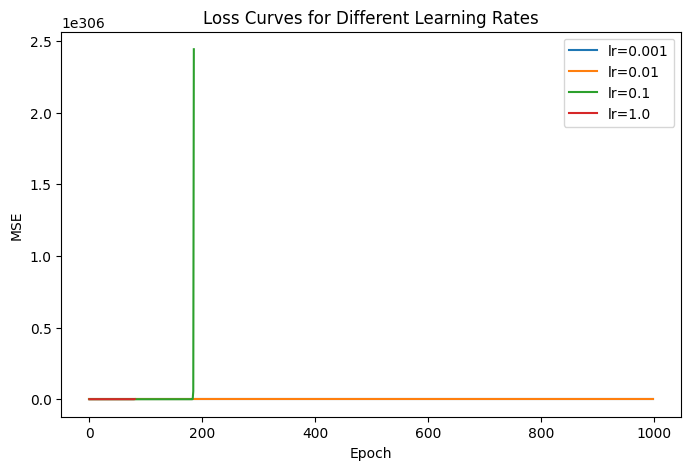

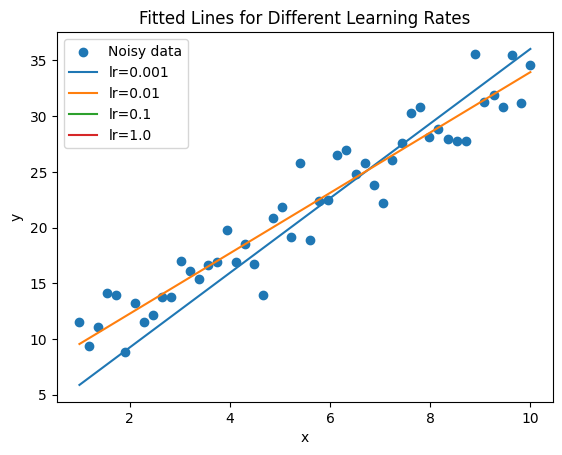

In [475]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(results[lr]["loss_history"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.show()

plt.scatter(x, y, label="Noisy data")

for lr in learning_rates:
    w = results[lr]["weights"]
    y_pred = X @ w
    plt.plot(x, y_pred, label=f"lr={lr}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted Lines for Different Learning Rates")
plt.legend()
plt.show()

## Multivariate Linear Regression

So far, we have worked with **simple linear regression**, where there is only one input feature:

$$
\hat{y} = w_0 + w_1x
$$

where:

- `w0` is the intercept/bias
- `w1` is the slope
- `x` is the input feature

In **multivariate linear regression**, we use multiple input features instead of just one.

For example, with three features:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + w_3x_3
$$

where:

- `w0` is the intercept/bias
- `w1`, `w2`, and `w3` are the feature weights
- `x1`, `x2`, and `x3` are different input features

More generally, for `D` features:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + \cdots + w_Dx_D
$$

---

## Matrix Form

To write this in matrix form, we add a column of ones to the data matrix so the model can learn the intercept.

For one data point:

$$
\mathbf{x} =
\begin{bmatrix}
1 \\
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$

and the weight vector is:

$$
\mathbf{w} =
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
w_3
\end{bmatrix}
$$

Then the prediction can be written as:

$$
\hat{y} = \mathbf{w}^\top \mathbf{x}
$$

For the full dataset, we write:

$$
\hat{\mathbf{y}} = X\mathbf{w}
$$

where `X` is the design matrix.

If we have `n` data points and three features, then:

$$
X =
\begin{bmatrix}
1 & x_{1,1} & x_{1,2} & x_{1,3} \\
1 & x_{2,1} & x_{2,2} & x_{2,3} \\
1 & x_{3,1} & x_{3,2} & x_{3,3} \\
\vdots & \vdots & \vdots & \vdots \\
1 & x_{n,1} & x_{n,2} & x_{n,3}
\end{bmatrix}
$$

The first column of ones is used to learn the bias/intercept term.

---

## Objective Function

The goal is still to choose weights that make the predictions close to the true values.

Using the residual sum of squares:

$$
RSS(\mathbf{w}) = \frac{1}{2}\|X\mathbf{w} - \mathbf{y}\|_2^2
$$

Equivalently:

$$
RSS(\mathbf{w}) = \frac{1}{2}(X\mathbf{w} - \mathbf{y})^\top(X\mathbf{w} - \mathbf{y})
$$

The goal is:

$$
\hat{\mathbf{w}} = \arg\min_{\mathbf{w}} RSS(\mathbf{w})
$$

---

## Closed-Form Solution

The gradient of the RSS objective is:

$$
\nabla_{\mathbf{w}}RSS(\mathbf{w}) = X^\top X\mathbf{w} - X^\top \mathbf{y}
$$

Setting the gradient equal to zero gives the normal equation:

$$
X^\top X\mathbf{w} = X^\top \mathbf{y}
$$

Solving for the weights:

$$
\mathbf{w} = (X^\top X)^{-1}X^\top \mathbf{y}
$$

In NumPy, instead of explicitly computing the inverse, we solve the system directly:

```python
w = np.linalg.solve(X.T @ X, X.T @ y)
```



Since the data was generated from:

$$
y = 5 + 3x_1 - 2x_2 + 4x_3 + \epsilon
$$

we expect the learned weights to be close to:

```python
w[0] ≈ 5
w[1] ≈ 3
w[2] ≈ -2
w[3] ≈ 4
```

They will not be exact because we added noise.

---

## Making Predictions

Once the weights are learned, predictions are computed the same way as before:

```python
y_pred = X @ w
```

Mathematically:

$$
\hat{\mathbf{y}} = X\mathbf{w}
$$

---

## Evaluating the Model

We can evaluate the model using `MSE`, `MAE`, and `R2`.

```python
# predictions
y_pred = X @ w

# mean squared error
mse = np.mean((y - y_pred) ** 2)

# mean absolute error
mae = np.mean(np.abs(y - y_pred))

# R-squared
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
```

---

## Main Difference From Simple Linear Regression

Simple linear regression uses one feature:

```python
X = np.c_[np.ones(len(x)), x]
```

Multivariate linear regression uses multiple features:

```python
X = np.c_[np.ones(n), x1, x2, x3]
```

The math stays the same:

$$
\hat{\mathbf{y}} = X\mathbf{w}
$$

$$
X^\top X\mathbf{w} = X^\top \mathbf{y}
$$

$$
\mathbf{w} = (X^\top X)^{-1}X^\top \mathbf{y}
$$

The only difference is that `X` now has more columns because we have more input features.

weights: [ 4.61827719  2.85534388 -1.85854912  4.25019838]
intercept: 4.618277191076985
w1: 2.8553438842679686
w2: -1.8585491227470363
w3: 4.2501983795709215
MSE: 3.3615412452638846
MAE: 1.4745655022468782
R2: 0.8928666706964654


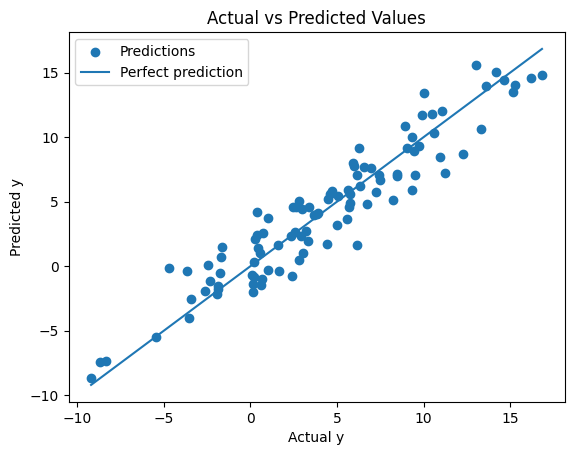

In [476]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# number of data points
n = 100

# features
x1 = np.random.randn(n)
x2 = np.random.randn(n)
x3 = np.random.randn(n)

# noise
noise = np.random.randn(n) * 2

# true relationship:
# y = 5 + 3*x1 - 2*x2 + 4*x3 + noise
y = 5 + 3*x1 - 2*x2 + 4*x3 + noise

# design matrix with bias column
X = np.c_[np.ones(n), x1, x2, x3]

# closed-form solution
w = np.linalg.solve(X.T @ X, X.T @ y)

print("weights:", w)
print("intercept:", w[0])
print("w1:", w[1])
print("w2:", w[2])
print("w3:", w[3])

# predictions
y_pred = X @ w

# evaluation
mse = np.mean((y - y_pred) ** 2)
mae = np.mean(np.abs(y - y_pred))
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

# plot actual vs predicted
plt.scatter(y, y_pred, label="Predictions")

# perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="-", label="Perfect prediction")

plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

## A more realistic example:

Here we can predict a fake house price where we have 

- square_feet
- bedrooms
- house age
- distance_to_city



In [477]:
np.random.seed(0)

# generate fake housing data

n = 200

# avg house size
square_feet = np.random.normal(1800, 500, n) 
# 1 to 5 bedrooms
bedrooms = np.random.randint(1, 6, n)
# house age in years
age = np.random.randint(0, 80, n)
# miles from city center 
distance_to_city = np.random.uniform(1, 40, n)

noise = np.random.normal(0,30000, n)

The true relationship

price = $50000$ + $180$ * square_feet + $15000$ *bedrooms - $1200$ * age - $2500$ *distance + noise$


In [478]:
y = (
    50000 + 180*square_feet
    + 15000 * bedrooms
    - 1200 * age 
    - 2500 * distance_to_city
    + noise
)

# Building the feature matrix X

X_features = np.c_[square_feet, bedrooms, age, distance_to_city]

# add bias col
X = np.c_[np.ones(n), X_features]



## Train/Test Split

Before evaluating a model, we usually split the data into two parts:

1. **Training data**: used to learn the weights.
2. **Testing data**: used to evaluate how well the model performs on unseen data.

This helps us check whether the model generalizes instead of only memorizing the training data.

---

## Creating Random Indices

```python
indices = np.arange(n)
```

If `n = 10`, then this creates:

```python
indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
```

These are the row indices of the dataset.

Then we shuffle them:

```python
np.random.shuffle(indices)
```

Example output:

```python
indices = [2, 8, 4, 9, 1, 6, 7, 3, 0, 5]
```

Now the data points are in random order.

---

## Choosing the Training Size

```python
train_size = int(0.8 * n)
```

This means we use 80% of the data for training.

If:

```python
n = 100
```

then:

```python
train_size = 80
```

So we use:

```python
80 points for training
20 points for testing
```

---

## Splitting the Indices

```python
train_index = indices[:train_size]
test_index = indices[train_size:]
```

The first line takes the first 80% of the shuffled indices:

```python
train_index = indices[:train_size]
```

The second line takes the remaining 20%:

```python
test_index = indices[train_size:]
```

Example with `n = 10`:

```python
indices = [2, 8, 4, 9, 1, 6, 7, 3, 0, 5]

train_size = 8

train_index = [2, 8, 4, 9, 1, 6, 7, 3]
test_index = [0, 5]
```

So rows `2, 8, 4, 9, 1, 6, 7, 3` are used for training, and rows `0, 5` are used for testing.

---

## Creating Training and Testing Data

```python
X_train = X[train_index]
X_test = X[test_index]

y_train = y[train_index]
y_test = y[test_index]
```

This selects the same rows from `X` and `y`.

That is important because each row of `X` corresponds to one value in `y`.

So if we use row `2` of `X`, we must also use row `2` of `y`.

The final split is:

```python
X_train  # input features used to train the model
y_train  # true outputs used to train the model

X_test   # input features used to test the model
y_test   # true outputs used to test the model
```

---

## Why We Do This

We fit the model using only the training data:

```python
w = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
```

Then we evaluate it on the testing data:

```python
y_test_pred = X_test @ w
```

This tells us how well the model performs on data it did not train on.

If the model does well on training data but poorly on testing data, it may be overfitting.

In [479]:
# Train/Test split

indices = np.arange(n)
np.random.shuffle(indices)

train_size = int(0.8 * n)

train_index = indices[:train_size]
test_index = indices[train_size:]

X_train = X[train_index]
X_test = X[test_index]

y_train = y[train_index]
y_test = y[test_index]

In [480]:
# fit using closed form

w = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
feature_names = ["intercept", "square_feet", "bedrooms", "age", "distance_to_city"]

print("Learned weights:")
for name, weight in zip(feature_names, w):
    print(f"  {name:<18}{weight:>12.4f}")

Learned weights:
  intercept           61185.7214
  square_feet           174.5042
  bedrooms            15791.6375
  age                 -1143.3571
  distance_to_city    -2483.6048


In [481]:
# Make predictions
y_train_pred = X_train @ w
y_test_pred = X_test @ w

# Evaluate Function

def evaluate(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)** 2) / np.sum((y_true - np.mean(y_true))**2)

    return mse, mae, r2

train_mse, train_mae, train_r2 = evaluate(y_train, y_train_pred)

test_mse, test_mae, test_r2 = evaluate(y_test, y_test_pred)

print()
print("Training performance:")
print("MSE:", train_mse)
print("MAE:", train_mae)
print("R2:", train_r2)
print()
print("Testing performance:")
print("MSE:", test_mse)
print("MAE:", test_mae)
print("R2:", test_r2)




Training performance:
MSE: 911688027.0845932
MAE: 24810.20676699343
R2: 0.9188498847508534

Testing performance:
MSE: 710416257.7687231
MAE: 21210.60653735148
R2: 0.918069924188772


Plotting the predicted vs. actual we get:


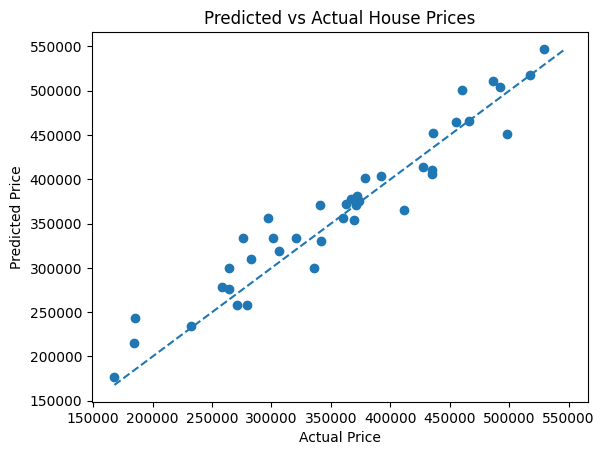

In [482]:
plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Predicted vs Actual House Prices")

# perfect prediction line

min_price = min(y_test.min(), y_test_pred.min())

max_price = max(y_test.max(), y_test_pred.max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.show()

# Stochastic and Mini-Batch Gradient Descent

So far, we have used **full-batch gradient descent** for linear regression.

In full-batch gradient descent, every update uses the entire dataset.

The prediction is:

$$
\hat{y} = Xw
$$

The Mean Squared Error objective is:

$$
MSE(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

The gradient of MSE is:

$$
\nabla_w MSE(w) = \frac{2}{n}X^\top(Xw - y)
$$

So the update rule is:

$$
w := w - \alpha \frac{2}{n}X^\top(Xw - y)
$$

where `alpha` is the learning rate.

---

## Full-Batch Gradient Descent

Full-batch gradient descent uses all `n` data points to compute one gradient update.

```python
gradient = (2 / n) * X.T @ error
w = w - learning_rate * gradient
```

This is stable because every update uses the full dataset.

However, for very large datasets, computing the full gradient can be slow.

---

## Stochastic Gradient Descent

Stochastic Gradient Descent, or `SGD`, updates the weights using one randomly chosen data point at a time.

For one data point, the prediction is:

$$
\hat{y}_i = x_i^\top w
$$

The error is:

$$
e_i = \hat{y}_i - y_i
$$

The one-sample gradient is:

$$
\nabla_w MSE_i(w) = 2x_i(\hat{y}_i - y_i)
$$

So the update rule becomes:

$$
w := w - \alpha \cdot 2x_i(\hat{y}_i - y_i)
$$

In code:

```python
xi = X[i]
yi = y[i]

y_pred_i = xi @ w
error_i = y_pred_i - yi

gradient = 2 * xi * error_i

w = w - learning_rate * gradient
```

SGD updates much more frequently than full-batch gradient descent, but each update is noisier because it only uses one example.

---

## Mini-Batch Gradient Descent

Mini-batch gradient descent is a compromise between full-batch gradient descent and SGD.

Instead of using all data points or only one data point, it uses a small batch of data points.

For example, if `batch_size = 32`, then each update uses 32 examples.

For a mini-batch, the gradient is:

$$
\nabla_w MSE_{batch}(w) = \frac{2}{m}X_{batch}^\top(X_{batch}w - y_{batch})
$$

where `m` is the batch size.

In code:

```python
y_pred_batch = X_batch @ w
error_batch = y_pred_batch - y_batch

gradient = (2 / len(y_batch)) * X_batch.T @ error_batch

w = w - learning_rate * gradient
```

Mini-batch gradient descent is commonly used in real machine learning because it is faster than full-batch gradient descent and less noisy than pure SGD.

---

## Comparison

| Method | Data used per update | Speed per update | Noise level |
|---|---:|---:|---:|
| Full-batch GD | All data | Slowest | Smoothest |
| SGD | 1 example | Fastest | Noisiest |
| Mini-batch GD | Small batch | Medium | Medium |

---

## Main Idea

Full-batch gradient descent uses the entire dataset for each update:

```python
gradient = (2 / n) * X.T @ error
```

SGD uses one example at a time:

```python
gradient = 2 * xi * error_i
```

Mini-batch gradient descent uses a small group of examples:

```python
gradient = (2 / batch_size) * X_batch.T @ error_batch
```

The update rule is always the same:

$$
w := w - \alpha \cdot gradient
$$

The only thing that changes is how much data we use to estimate the gradient.

## Testing

In [483]:
np.random.seed(0)

# generate synthetic data
n = 100_000

x1 = np.random.randn(n)
x2 = np.random.randn(n)
x3 = np.random.randn(n)

noise = np.random.randn(n) * 2

# true model:
# y = 5 + 3*x1 - 2*x2 + 4*x3 + noise
y = 5 + 3*x1 - 2*x2 + 4*x3 + noise

# design matrix with bias column
X = np.c_[np.ones(n), x1, x2, x3]

# closed-form answer for comparison
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

print("Closed-form weights:", w_closed)

Closed-form weights: [ 5.01051194  3.00800152 -2.00482445  3.99848853]


In [484]:
import time
def full_batch_gradient_descent(X, y, learning_rate = 0.01, epochs = 100):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []
    
    start = time.time()
    
    for epoch in range(epochs):
        y_pred = X @ w
        error = y_pred - y
        
        mse = np.mean(error ** 2)
        loss_history.append(mse)
        
        gradient = (2/n) * X.T @ error
        
        w = w - learning_rate * gradient 
        
    end = time.time()
    
    speed = end - start
    
    return w, loss_history, speed

# Stochastic Gradient Descent - updating weights using one random
# point at a time

def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs =5):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []
    
    start = time.time()
    
    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)
        
        for i in indices:
            xi = X[i]
            yi = y[i]
            
            y_pred_i = xi @ w
            error_i = y_pred_i - yi
            ############################
            gradient = 2 * xi * error_i 
            ###########################
            # one sample version
            
            w = w - learning_rate * gradient
        # calculate full loss once per epoch
        y_pred = X @ w
        mse = np.mean((y_pred - y)**2)
        loss_history.append(mse)
        
    end = time.time()
    speed = end - start
    
    return w, loss_history, speed

# Mini-Batch Gradient Descent - uses a small batch of examples per update
def mini_batch_gradient_descent(X, y, learning_rate = 0.01, epochs = 10, batch_size = 32):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []
    
    start = time.time()
    
    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)
        
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for start_index in range(0, n, batch_size):
            end_index = start_index + batch_size
            
            X_batch = X_shuffled[start_index:end_index]
            y_batch = y_shuffled[start_index:end_index]
            
            y_pred_batch = X_batch @ w
            error_batch = y_pred_batch - y_batch
            
            gradient = (2 / len(y_batch)) * X_batch.T @ error_batch
            
            w = w - learning_rate * gradient 
            
        # calculate full loss once per epoch
        y_pred = X @ w 
        mse = np.mean((y_pred - y) ** 2)
        loss_history.append(mse)
        
    end = time.time()
    
    speed = end - start
    
    return w, loss_history, speed     

            

We can start on this dataset:

In [485]:
w_full, loss_full, time_full = full_batch_gradient_descent(
    X, y,
    learning_rate=0.01,
    epochs=100
)

w_sgd, loss_sgd, time_sgd = stochastic_gradient_descent(
    X, y,
    learning_rate=0.001,
    epochs=5
)

w_mini, loss_mini, time_mini = mini_batch_gradient_descent(
    X, y,
    learning_rate=0.01,
    epochs=10,
    batch_size=32
)

print("Closed-form weights:", w_closed)
print()

print("Full-batch GD weights:", w_full)
print("Time:", time_full)
print("Final loss:", loss_full[-1])
print()

print("SGD weights:", w_sgd)
print("Time:", time_sgd)
print("Final loss:", loss_sgd[-1])
print()

print("Mini-batch GD weights:", w_mini)
print("Time:", time_mini)
print("Final loss:", loss_mini[-1])

Closed-form weights: [ 5.01051194  3.00800152 -2.00482445  3.99848853]

Full-batch GD weights: [ 4.34217027  2.61170141 -1.73426205  3.47242139]
Time: 0.028469085693359375
Final loss: 4.982150564743271

SGD weights: [ 5.07776237  3.02176299 -2.01704681  4.1355406 ]
Time: 1.2735671997070312
Final loss: 4.013117736218924

Mini-batch GD weights: [ 5.02433292  2.95425085 -1.98069702  4.03495944]
Time: 0.1163473129272461
Final loss: 3.994417850165958


**Note:** SGD shows the slowest *wall-clock* time here not because the algorithm is slow, but because it runs a pure-Python loop over all `n` samples one at a time (NumPy can't vectorize one sample per update), whereas full-batch and mini-batch do their work in vectorized matrix operations.

### Plotting the Loss Curves

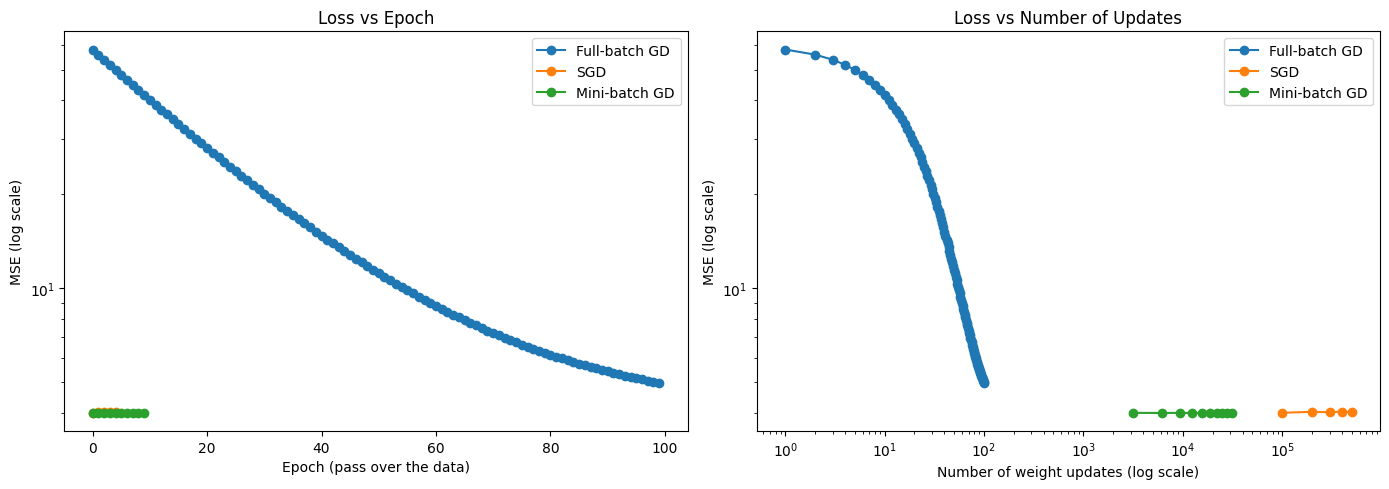

In [486]:
# Two honest ways to compare the methods.
#
# Plotting raw loss vs "epoch" is misleading here: the histories have
# different lengths (full=100, sgd=5, mini=10), and one epoch means very
# different amounts of work for each method (full-batch = 1 weight update,
# SGD = n updates, mini-batch = n/batch_size updates).

# weight updates per recorded loss point (we log loss once per epoch)
updates_full = np.arange(1, len(loss_full) + 1) * 1                      # 1 update / epoch
updates_sgd  = np.arange(1, len(loss_sgd) + 1) * len(y)                  # n updates / epoch
updates_mini = np.arange(1, len(loss_mini) + 1) * int(np.ceil(len(y) / 32))  # batches / epoch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# View 1: loss vs epoch, log y-scale so the curves aren't squashed by
# full-batch's large starting loss (~58 at w = 0).
axes[0].plot(loss_full, marker="o", label="Full-batch GD")
axes[0].plot(loss_sgd, marker="o", label="SGD")
axes[0].plot(loss_mini, marker="o", label="Mini-batch GD")
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch (pass over the data)")
axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("Loss vs Epoch")
axes[0].legend()

# View 2: loss vs number of weight updates (the fair comparison).
# SGD reaches a low loss in far fewer passes because each pass makes n updates.
axes[1].plot(updates_full, loss_full, marker="o", label="Full-batch GD")
axes[1].plot(updates_sgd, loss_sgd, marker="o", label="SGD")
axes[1].plot(updates_mini, loss_mini, marker="o", label="Mini-batch GD")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of weight updates (log scale)")
axes[1].set_ylabel("MSE (log scale)")
axes[1].set_title("Loss vs Number of Updates")
axes[1].legend()

plt.tight_layout()
plt.show()

# Regularization: Ridge and Lasso Regression

So far, we have fit linear regression by minimizing prediction error.

For ordinary least squares, the objective is:

$$
RSS(w) = \frac{1}{2}\|Xw - y\|_2^2
$$

or using Mean Squared Error:

$$
MSE(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

where:

$$
\hat{y} = Xw
$$

However, if the model has many features, especially correlated features, ordinary linear regression can **overfit**.

Overfitting means the model fits the training data too closely and may not generalize well to new data.

Regularization fixes this by adding a penalty term to the loss.

---

## Why Regularization Helps

The regular linear regression objective only cares about prediction error:

$$
MSE(w)
$$

Regularized regression cares about prediction error and the size of the weights:

$$
MSE(w) + \text{penalty}
$$

The penalty discourages the model from using very large weights.

Large weights usually mean the model is relying too heavily on specific features, which can make the model unstable.

---

## Ridge Regression

Ridge regression adds an `L2` penalty:

$$
MSE(w) + \lambda \|w\|_2^2
$$

where:

$$
\|w\|_2^2 = \sum_{j=1}^{d} w_j^2
$$

So the Ridge objective is:

$$
J(w) = \frac{1}{n}\|Xw - y\|_2^2 + \lambda \sum_{j=1}^{d} w_j^2
$$

The value `lambda` controls the strength of regularization.

If `lambda = 0`, Ridge becomes ordinary linear regression.

If `lambda` is large, the weights are pushed closer to zero.

---

## Important Note About the Bias Term

Usually, we do not regularize the bias/intercept term.

If:

```python
w[0]  # intercept
w[1:] # feature weights
```

then we apply the Ridge penalty only to:

```python
w[1:]
```

The intercept just shifts the prediction up or down, so we usually do not penalize it.

---

## Ridge Gradient

For regular MSE, the gradient is:

$$
\nabla_w MSE(w) = \frac{2}{n}X^\top(Xw - y)
$$

For Ridge, we add the gradient of the penalty:

$$
\nabla_w \lambda \|w\|_2^2 = 2\lambda w
$$

So the full Ridge gradient is:

$$
\nabla_w J(w) = \frac{2}{n}X^\top(Xw - y) + 2\lambda w
$$

But because we usually do not penalize the intercept, in code we use:

```python
ridge_gradient = (2 / n) * X.T @ error

ridge_gradient[1:] += 2 * lambda_value * w[1:]
```

Then we update:

```python
w = w - learning_rate * ridge_gradient
```

---

## Lasso Regression

Lasso regression adds an `L1` penalty:

$$
MSE(w) + \lambda \|w\|_1
$$

where:

$$
\|w\|_1 = \sum_{j=1}^{d}|w_j|
$$

So the Lasso objective is:

$$
J(w) = \frac{1}{n}\|Xw - y\|_2^2 + \lambda \sum_{j=1}^{d}|w_j|
$$

The main difference is:

```text
Ridge shrinks weights toward zero.
Lasso can shrink some weights exactly to zero.
```

This makes Lasso useful for feature selection.

---

## Lasso Subgradient

The derivative of `abs(w)` is not defined exactly at zero, so Lasso uses a subgradient.

For nonzero values:

$$
\frac{d}{dw}|w| = sign(w)
$$

So the Lasso gradient is approximately:

$$
\nabla_w J(w) = \frac{2}{n}X^\top(Xw - y) + \lambda sign(w)
$$

Again, we usually do not penalize the intercept:

```python
lasso_gradient = (2 / n) * X.T @ error

lasso_gradient[1:] += lambda_value * np.sign(w[1:])
```

Then:

```python
w = w - learning_rate * lasso_gradient
```

---

## Ridge vs Lasso

| Method | Penalty | Effect |
|---|---|---|
| Linear Regression | none | Fits weights only based on error |
| Ridge | `L2`, sum of squared weights | Shrinks weights toward zero |
| Lasso | `L1`, sum of absolute weights | Can make some weights exactly zero |

---

## Main Idea

Regularization changes the objective from:

$$
MSE(w)
$$

to:

$$
MSE(w) + \lambda \cdot penalty
$$

The larger `lambda` is, the more the model is punished for large weights.

Ridge is useful when many features matter a little.

Lasso is useful when only a few features matter and we want feature selection.

## Code for Ridge and Lasso Regression

In [487]:

# Ridge Regression 
def ridge_gradient_descent(X, y, lambda_value = 0.1, learning_rate = 0.01, epochs = 1000):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []
    
    for epoch in range(epochs):
        y_pred = X @ w
        error = y_pred - y
        
        mse = np.mean(error ** 2)
        ridge_penalty = lambda_value * np.sum(w[1:] ** 2)
        
        loss = mse + ridge_penalty
        loss_history.append(loss)
        
        gradient = (2 / n) * X.T @ error 
        # do not regularize intercept
        gradient[1:] += 2 * lambda_value * w[1:]
        
        w = w - learning_rate * gradient 
        
    return w, loss_history

# Lasso Regression 

def lasso_gradient_descent(X, y, lambda_value = 0.1, learning_rate = 0.01, epochs = 1000):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []
    
    for epoch in range(epochs):
        y_pred = X @ w
        error = y_pred - y
        
        mse = np.mean(error ** 2)
        lasso_penalty = lambda_value * np.sum(np.abs(w[1:]))
        
        loss = mse + lasso_penalty
        loss_history.append(loss)
        
        gradient = (2 / n) * X.T @ error 
        
        # do not regularize this intercept 
        gradient[1:] += lambda_value * np.sign(w[1:])
        
        w = w - learning_rate * gradient 
        
    return w, loss_history

## Testing and Comparison

In [488]:
np.random.seed(0)

# number of data points and features 
n = 500
d = 20

# generate random features
X_features = np.random.randn(n, d)

# true weights: only 3 features matter
true_w = np.zeros(d)
true_w[0] = 5
true_w[3] = -3
true_w[7] = 2

# intercept
true_intercept = 10

# noise 
noise = np.random.randn(n) * 2

# generate y
y = true_intercept + X_features @ true_w + noise

# add bias column
X = np.c_[np.ones(n), X_features]



### Train/Test Split 

In [489]:
indices = np.arange(n)
np.random.shuffle(indices)

train_size = int(0.8 * n)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

### Evaluate Function


In [490]:
def evaluate(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    
    return mse, mae, r2

### Ordinary Linear Regression

In [491]:
w_plain = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)

y_train_pred_plain = X_train @ w_plain
y_test_pred_plain = X_test @ w_plain

train_mse, train_mae, train_r2 = evaluate(y_train, y_train_pred_plain)
test_mse, test_mae, test_r2 = evaluate(y_test, y_test_pred_plain)

print("Plain Linear Regression")
print("Train MSE:", train_mse)
print("Train MAE:", train_mae)
print("Train R2:", train_r2)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)
print("Weights:", w_plain)

Plain Linear Regression
Train MSE: 3.5838139979458496
Train MAE: 1.5364261303965554
Train R2: 0.9082438176657435
Test MSE: 4.036597100814203
Test MAE: 1.5997561881585431
Test R2: 0.9172450662725559
Weights: [ 1.01525089e+01  4.92128986e+00  3.73874528e-03 -7.53579952e-02
 -2.97252385e+00  2.44141199e-02 -8.38026205e-03 -9.46166246e-02
  1.75830287e+00 -2.16465794e-02 -1.37291824e-01  1.05870298e-01
  2.54345106e-02  6.04042764e-02 -8.17228193e-02 -2.12386846e-01
 -7.79122290e-03 -4.97940363e-02 -4.56345372e-02 -6.52172346e-02
 -6.18711162e-02]


### Ridge 

In [492]:
w_ridge, ridge_loss = ridge_gradient_descent(
    X_train,
    y_train,
    lambda_value=0.1,
    learning_rate=0.01,
    epochs=1000
)

y_train_pred_ridge = X_train @ w_ridge
y_test_pred_ridge = X_test @ w_ridge

train_mse, train_mae, train_r2 = evaluate(y_train, y_train_pred_ridge)
test_mse, test_mae, test_r2 = evaluate(y_test, y_test_pred_ridge)

print("Ridge Regression")
print("Train MSE:", train_mse)
print("Train MAE:", train_mae)
print("Train R2:", train_r2)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)
print("Weights:", w_ridge)

Ridge Regression
Train MSE: 3.8958341236112033
Train MAE: 1.5780260765848642
Train R2: 0.9002551844501476
Test MSE: 4.102685606084793
Test MAE: 1.6036616599887166
Test R2: 0.9158901750765258
Weights: [ 1.01681549e+01  4.45340443e+00  1.19604393e-02 -5.24762282e-02
 -2.67171872e+00  2.96681770e-02  2.71622075e-04 -2.50225489e-02
  1.62134744e+00 -8.12297413e-03 -1.45894879e-01  1.20933247e-01
  3.22309838e-02  4.00224174e-02 -5.81108103e-02 -1.70329964e-01
 -1.04512419e-03 -3.55782338e-02 -4.76985419e-02 -2.13699146e-02
 -4.98984924e-02]


### Lasso 

In [493]:
w_lasso, lasso_loss = lasso_gradient_descent(
    X_train,
    y_train,
    lambda_value=0.1,
    learning_rate=0.01,
    epochs=1000
)

y_train_pred_lasso = X_train @ w_lasso
y_test_pred_lasso = X_test @ w_lasso

train_mse, train_mae, train_r2 = evaluate(y_train, y_train_pred_lasso)
test_mse, test_mae, test_r2 = evaluate(y_test, y_test_pred_lasso)

print("Lasso Regression")
print("Train MSE:", train_mse)
print("Train MAE:", train_mae)
print("Train R2:", train_r2)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)
print("Weights:", w_lasso)

Lasso Regression
Train MSE: 3.6195842439144417
Train MAE: 1.542554201855073
Train R2: 0.907327994128831
Test MSE: 3.9021020984502233
Test MAE: 1.5652620923625948
Test R2: 0.9200023701920029
Weights: [ 1.01539089e+01  4.86365163e+00 -9.10735357e-04 -3.39913354e-02
 -2.90134089e+00  1.10405409e-03 -1.01146686e-03 -3.96131847e-02
  1.71201226e+00  9.18522029e-04 -8.15091303e-02  6.76144139e-02
  1.26467118e-03  8.43840006e-03 -1.87153017e-02 -1.71133033e-01
  3.52661851e-04 -1.91121658e-03 -9.48708397e-04 -2.49742815e-02
 -1.58051634e-03]


## Lasso with Soft-Thresholding (Proximal Gradient)

The subgradient version above shrinks weights toward zero but almost never makes them *exactly* zero, so it cannot do true feature selection. The fix is **proximal gradient descent** (also called ISTA), which splits each step in two:

1. A normal gradient step on the smooth MSE part only.
2. A **soft-thresholding** step on the penalized weights:

$$
\text{soft}(z, t) = \text{sign}(z)\,\max(|z| - t,\ 0)
$$

with threshold $t = \alpha\lambda$ (learning rate times lambda). Any weight whose magnitude falls below the threshold is snapped to **exactly zero** -- this is what gives Lasso its feature-selection behavior. The intercept `w[0]` is not penalized, so we leave it out of the thresholding.

In [494]:
def soft_threshold(z, thresh):
    # proximal operator of the L1 norm: shrink each value toward 0 by `thresh`,
    # and anything within `thresh` of 0 becomes exactly 0
    return np.sign(z) * np.maximum(np.abs(z) - thresh, 0.0)


def lasso_proximal_gradient_descent(X, y, lambda_value=1.0, learning_rate=0.01, epochs=1000):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        error = X @ w - y

        mse = np.mean(error ** 2)
        lasso_penalty = lambda_value * np.sum(np.abs(w[1:]))
        loss_history.append(mse + lasso_penalty)

        # 1) gradient step on the smooth (MSE) part only
        w = w - learning_rate * (2 / n) * X.T @ error

        # 2) proximal step: soft-threshold the penalized weights toward 0.
        #    The intercept w[0] is not penalized, so leave it untouched.
        w[1:] = soft_threshold(w[1:], learning_rate * lambda_value)

    return w, loss_history


# run it and compare exact-zero counts against the subgradient Lasso above
w_lasso_prox, lasso_prox_loss = lasso_proximal_gradient_descent(
    X_train, y_train, lambda_value=1.0, learning_rate=0.01, epochs=1000
)

print("Subgradient Lasso  exact zeros:", np.sum(w_lasso[1:] == 0), "/", d)
print("Proximal   Lasso   exact zeros:", np.sum(w_lasso_prox[1:] == 0), "/", d)
print()
print("Proximal Lasso weights:")
print(np.round(w_lasso_prox, 3))
print()
print("True weights:")
print(np.round(np.r_[true_intercept, true_w], 3))

Subgradient Lasso  exact zeros: 0 / 20
Proximal   Lasso   exact zeros: 17 / 20

Proximal Lasso weights:
[10.175  4.393  0.    -0.    -2.415  0.     0.    -0.     1.322  0.
 -0.     0.     0.     0.    -0.    -0.     0.    -0.    -0.    -0.
  0.   ]

True weights:
[10.  5.  0.  0. -3.  0.  0.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.]


### Compare Coefficients 

In [495]:
feature_names = ["intercept"] + [f"x{i}" for i in range(1, d + 1)]

print("True weights:")
print(np.r_[true_intercept, true_w])

print()
print("Plain weights:")
print(w_plain)

print()
print("Ridge weights:")
print(w_ridge)

print()
print("Lasso weights:")
print(w_lasso)

True weights:
[10.  5.  0.  0. -3.  0.  0.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.]

Plain weights:
[ 1.01525089e+01  4.92128986e+00  3.73874528e-03 -7.53579952e-02
 -2.97252385e+00  2.44141199e-02 -8.38026205e-03 -9.46166246e-02
  1.75830287e+00 -2.16465794e-02 -1.37291824e-01  1.05870298e-01
  2.54345106e-02  6.04042764e-02 -8.17228193e-02 -2.12386846e-01
 -7.79122290e-03 -4.97940363e-02 -4.56345372e-02 -6.52172346e-02
 -6.18711162e-02]

Ridge weights:
[ 1.01681549e+01  4.45340443e+00  1.19604393e-02 -5.24762282e-02
 -2.67171872e+00  2.96681770e-02  2.71622075e-04 -2.50225489e-02
  1.62134744e+00 -8.12297413e-03 -1.45894879e-01  1.20933247e-01
  3.22309838e-02  4.00224174e-02 -5.81108103e-02 -1.70329964e-01
 -1.04512419e-03 -3.55782338e-02 -4.76985419e-02 -2.13699146e-02
 -4.98984924e-02]

Lasso weights:
[ 1.01539089e+01  4.86365163e+00 -9.10735357e-04 -3.39913354e-02
 -2.90134089e+00  1.10405409e-03 -1.01146686e-03 -3.96131847e-02
  1.71201226e+00  9.18522029e-04 -8

### Plotting Coefficients 

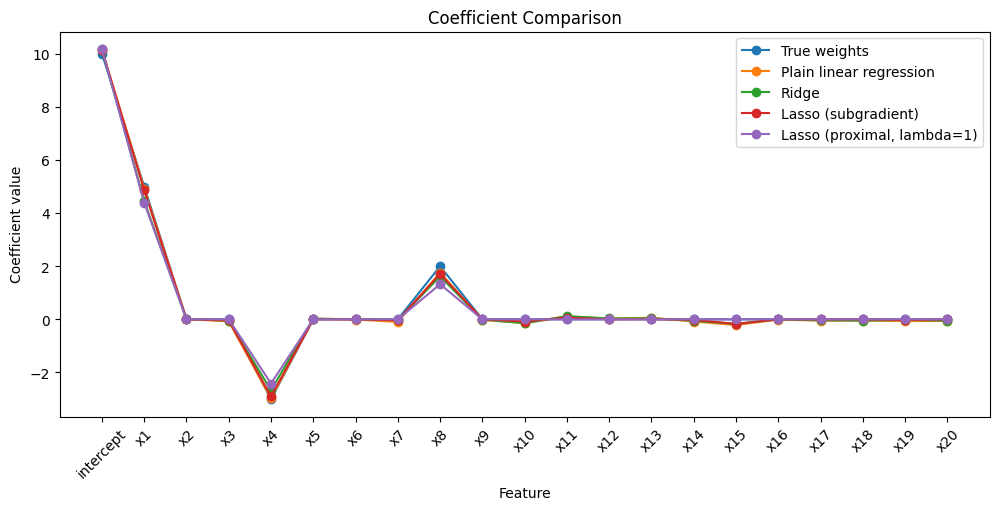

In [496]:
plt.figure(figsize=(12, 5))

x_axis = np.arange(d + 1)

plt.plot(x_axis, np.r_[true_intercept, true_w], marker="o", label="True weights")
plt.plot(x_axis, w_plain, marker="o", label="Plain linear regression")
plt.plot(x_axis, w_ridge, marker="o", label="Ridge")
plt.plot(x_axis, w_lasso, marker="o", label="Lasso (subgradient)")
plt.plot(x_axis, w_lasso_prox, marker="o", label="Lasso (proximal, lambda=1)")

plt.xticks(x_axis, feature_names, rotation=45)
plt.xlabel("Feature")
plt.ylabel("Coefficient value")
plt.title("Coefficient Comparison")
plt.legend()
plt.show()

### Regularization Path: Sweeping lambda

As `lambda` grows, the L1 penalty gets stronger and the proximal Lasso snaps more coefficients to **exactly zero**. Plotting each coefficient against `lambda` gives the classic **Lasso path**: the three true features survive longest, while the irrelevant ones drop to zero early.

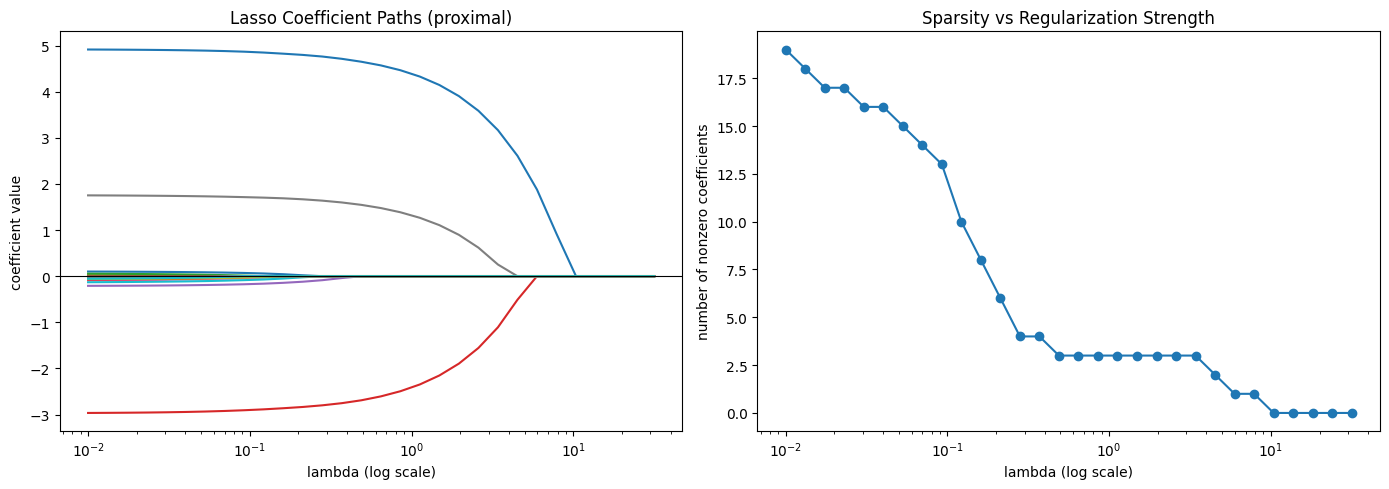

In [499]:
# sweep lambda and record the proximal-Lasso solution at each value
lambdas = np.logspace(-2, 1.5, 30)   # 0.01 ... ~31

paths = []
nonzeros = []
for lam in lambdas:
    w_lam, _ = lasso_proximal_gradient_descent(
        X_train, y_train, lambda_value=lam, learning_rate=0.01, epochs=1000
    )
    paths.append(w_lam[1:])              # feature weights only (skip intercept)
    nonzeros.append(np.sum(w_lam[1:] != 0))

paths = np.array(paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: coefficient path for every feature
for j in range(d):
    axes[0].plot(lambdas, paths[:, j])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("lambda (log scale)")
axes[0].set_ylabel("coefficient value")
axes[0].set_title("Lasso Coefficient Paths (proximal)")

# right: how many features stay nonzero
axes[1].plot(lambdas, nonzeros, marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("lambda (log scale)")
axes[1].set_ylabel("number of nonzero coefficients")
axes[1].set_title("Sparsity vs Regularization Strength")

plt.tight_layout()
plt.show()